In [1]:
import numpy as np
from sklearn.metrics import mean_squared_error
import warnings
import scipy.linalg
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=scipy.linalg.LinAlgWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ================================
# Helper: RMSE
# ================================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ================================
# Hybrid Echo State Network (manual ridge)
# ================================
class HESN:
    def __init__(self, n_input, n_reservoir, n_output,
                 spectral_radius=1.2, input_scaling=0.1, kb_scale=0.0,
                 leak_factor=1.0, tikhonov=1e-6, connectivity=0.5, random_state=42, dtype = np.float32):

        self.rng = np.random.RandomState(random_state)
        self.n_input = n_input
        self.n_reservoir = n_reservoir
        self.n_output = n_output
        self.spectral_radius = spectral_radius
        self.input_scaling = input_scaling
        self.kb_scale = kb_scale
        self.leak_factor = leak_factor
        self.tikhonov = tikhonov
        self.connectivity = connectivity
        self.dtype = np.float32

        # Input + KB weights
        self.W_in = self.rng.uniform(-self.input_scaling, self.input_scaling,
                                     (n_reservoir, n_input)).astype(self.dtype)
        self.W_kb = self.rng.uniform(-self.kb_scale, self.kb_scale,
                                     (n_reservoir, n_input)).astype(self.dtype)

        # Reservoir weights
        W = self.rng.uniform(-1, 1, (n_reservoir, n_reservoir)).astype(self.dtype)
        W *= (self.rng.rand(n_reservoir, n_reservoir) < connectivity)
        eigvals = np.abs(np.linalg.eigvals(W))  # safer in double
        maxeig = np.max(eigvals) if np.max(eigvals) != 0 else 1.0
        self.W = ((W / maxeig) * spectral_radius).astype(self.dtype)

        # Will hold output weights
        self.W_out = None

    def _run_reservoir(self, U, K, washout=0, x_init=None):
        U = U.astype(self.dtype)
        K = K.astype(self.dtype)
        if U is None or U.shape[0] == 0:
            x = np.zeros(self.n_reservoir, dtype=self.dtype) if x_init is None else x_init.copy()
            return np.zeros((0, self.n_reservoir), dtype=self.dtype), x

        x = np.zeros(self.n_reservoir, dtype=self.dtype) if x_init is None else x_init.copy().astype(self.dtype)
        T = U.shape[0]
        states = np.zeros((T, self.n_reservoir), dtype=self.dtype)
        for t in range(T):
            x = (1 - self.leak_factor) * x + self.leak_factor * np.tanh(
                self.W @ x + self.W_in @ U[t] + self.W_kb @ K[t]
            ).astype(self.dtype)
            states[t] = x
        return states[washout:], x

    def fit(self, U_washout, K_washout, U_input, K_input, Y_label):
        # Convert to consistent dtype (float32 or float64)
        U_input = U_input.astype(self.dtype)
        K_input = K_input.astype(self.dtype)
        Y_label = Y_label.astype(self.dtype)

        # --- Run reservoir ---
        if U_washout is not None and U_washout.shape[0] > 0:
            _, x_wash = self._run_reservoir(
                U_washout.astype(self.dtype),
                K_washout.astype(self.dtype)
            )
            states, _ = self._run_reservoir(U_input, K_input, x_init=x_wash)
        else:
            states, _ = self._run_reservoir(U_input, K_input)

        # --- Ridge regression ---
        S = np.nan_to_num(states.astype(self.dtype))
        Y = np.nan_to_num(Y_label.astype(self.dtype))

        A = S.T @ S + self.tikhonov * np.eye(S.shape[1], dtype=self.dtype)
        B = S.T @ Y

        # Try direct solve; fall back to pseudo-inverse if singular
        try:
            self.W_out = np.linalg.solve(A, B).astype(self.dtype)
        except np.linalg.LinAlgError:
            #print("[Warning] Singular matrix encountered; using pseudo-inverse instead.")
            self.W_out = (np.linalg.pinv(A) @ B).astype(self.dtype)
        return self





    def forecast_autonomous(self, U_washout, K_washout, u0, k_future, horizon):
        if self.W_out is None:
            raise RuntimeError("Model must be fit before forecasting.")

        dtype = self.dtype
        if U_washout is not None and U_washout.shape[0] > 0:
            _, x = self._run_reservoir(U_washout.astype(dtype), K_washout.astype(dtype))
        else:
            x = np.zeros(self.n_reservoir, dtype=dtype)

        u = u0.copy().astype(dtype).reshape(-1)
        preds = np.zeros((horizon, self.n_output), dtype=dtype)
        for t in range(horizon):
            k_t = k_future[t].astype(dtype)
            x = (1 - self.leak_factor) * x + self.leak_factor * np.tanh(
                self.W @ x + self.W_in @ u + self.W_kb @ k_t
            ).astype(dtype)
            y = (x @ self.W_out).astype(dtype)
            preds[t] = y.copy() # Ensure y is copied to avoid modifying it in the next iteration if n_output > 1
            u = y.copy()
        return preds


# ================================
# Generate Mackey–Glass data
# ================================
def Mackey_Glass(xt, xtau, a=0.2, b=0.1, n=10):
    return -b * xt + a * xtau / (1 + xtau**n)

def Mackey_Glass_rk4(xt, xtau, a=0.2, b=0.1, n=10, h=0.1):
    k1 = h * Mackey_Glass(xt, xtau, a, b, n)
    k2 = h * Mackey_Glass(xt + 0.5 * k1, xtau, a, b, n)
    k3 = h * Mackey_Glass(xt + 0.5 * k2, xtau, a, b, n)
    k4 = h * Mackey_Glass(xt + k3, xtau, a, b, n)
    return xt + (k1 + 2*k2 + 2*k3 + k4) / 6.0


# --- Parameters ---
a_true, b_true, n_true = 0.2, 0.1, 10
tau, dt = 17.0, 0.1
total_points = 150001
history_length = int(tau / dt)
epsilon = 0.1  # model error for KB model
noise_scale = 0.0

# ================================
# Noise utility
# ================================
def add_relative_gaussian_noise(X_clean, noise_scale):
    """Adds relative Gaussian noise to X_clean (each variable scaled by its std)."""
    signal_std = np.std(X_clean, axis=1, keepdims=True)
    noise = np.random.normal(0.0, noise_scale * signal_std, X_clean.shape)
    return X_clean + noise

# ================================
# Ground-truth MG system
# ================================
np.random.seed(2025)
buffer = 1.2 + np.random.rand(history_length)
series_length = total_points + history_length
x = np.zeros(series_length)
x[:history_length] = buffer

for t in range(history_length, series_length - 1):
    xt = x[t]
    xtau = x[t - history_length]
    x[t + 1] = Mackey_Glass_rk4(xt, xtau, a_true, b_true, n_true, h=dt)

mg_series = x[history_length:].reshape(1, -1)
mg_series_sampled = mg_series[:, ::10]

np.random.seed(2025)
# --- Add noise before normalization ---
mg_noisy = add_relative_gaussian_noise(mg_series_sampled, noise_scale)

U_rk4 = mg_noisy.T.astype(np.float32)
print(f"Ground-truth MG shape (noise {noise_scale*100:.0f}%):", U_rk4.shape)

# ================================
# Knowledge-based MG (imperfect model)
# ================================
a_kb = a_true
b_kb = b_true * (1 + epsilon)

x_kb = np.zeros(series_length)
x_kb[:history_length] = buffer.copy()
for t in range(history_length, series_length - 1):
    xt = x_kb[t]
    xtau = x_kb[t - history_length]
    x_kb[t + 1] = Mackey_Glass_rk4(xt, xtau, a_kb, b_kb, n_true, h=dt)

mg_kb = x_kb[history_length:].reshape(1, -1)
mg_kb_sampled = mg_kb[:, ::10]
K_rk4 = mg_kb_sampled.T.astype(np.float32)
print("Knowledge-based MG (imperfect model) shape:", K_rk4.shape)

# ================================
# Train / validation split
# ================================
dt = 1.0
warmup, traintime, valtime, testtime = 1000.0, 7000.0, 1000.0, 1000.0
warmup_pts   = int(round(warmup / dt))
traintime_pts = int(round(traintime / dt))
valtime_pts   = int(round(valtime / dt))
testtime_pts  = int(round(testtime / dt))

train_washout_size = warmup_pts
val_washout_size   = 1000
test_washout_size  = 1000
train_size = traintime_pts
val_size   = valtime_pts

train_end = train_washout_size + train_size
val_end   = train_end + val_size

U_train_washout = U_rk4[:train_washout_size, :]
K_train_washout = K_rk4[:train_washout_size, :]
U_train_input   = U_rk4[train_washout_size:train_end, :]
K_train_input   = K_rk4[train_washout_size:train_end, :]
U_train_label   = U_rk4[train_washout_size+1:train_end+1, :]

U_val_washout = U_rk4[train_end - val_washout_size:train_end, :]
K_val_washout = K_rk4[train_end - val_washout_size:train_end, :]
U_val_input   = U_rk4[train_end:val_end, :]
K_val_input   = K_rk4[train_end:val_end, :]
U_val_label   = U_rk4[train_end+1:val_end+1, :]

# ================================
# Grid search
# ================================
N_res_grid = [100] # fixed
rho_grid   = [0.80, 0.85, 0.90, 0.99, 1.05, 1.15, 1.25, 1.55]                    # 8
input_grid = [0.02, 0.05, 0.10, 0.20, 0.50, 0.80]                                # 6
leak_grid  = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]              # 9
tikh_grid  = [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3, 1e4] # 12   same as the NG-RC
conn_grid  = [0.01, 0.02, 0.05, 0.10, 0.15, 0.20]                                # 6
kb_grid    = [0.02, 0.05, 0.10, 0.20, 0.50, 0.80]                                # 6 knowledge-scale hyperparameter

# 8*6*9*12*6*6 = 186,624

num_runs = 1
horizons = [25, 50, 75, 100]
window_size = 100

all_results = []
best_config, best_rmse = None, float("inf")

print("Starting HESN grid search for MG system...")
PRINT_EVERY = 1000   # <-- change this to whatever you want
counter = 0         # count grid iterations

for N_res in N_res_grid:
    for rho in rho_grid:
        for input_scaling in input_grid:
            for leak in leak_grid:
                for tikh in tikh_grid:
                    for conn in conn_grid:
                        for kb_scale in kb_grid:
                            counter += 1  # increment grid iteration count
                            all_run_rmses = {h: [] for h in horizons}
                            for run in range(num_runs):
                                seed = 2025 + run

                                hesn = HESN(
                                    n_input=U_train_input.shape[1],
                                    n_reservoir=N_res,
                                    n_output=U_train_input.shape[1],
                                    spectral_radius=rho,
                                    input_scaling=input_scaling,
                                    kb_scale=kb_scale,
                                    leak_factor=leak,
                                    tikhonov=tikh,
                                    connectivity=conn,
                                    random_state=seed
                                )

                                hesn.fit(U_train_washout, K_train_washout,
                                         U_train_input, K_train_input, U_train_label)

                                val_len = U_val_input.shape[0]
                                num_windows = val_len // window_size
                                max_h = max(horizons)
                                horizon_rmses = {h: [] for h in horizons}

                                for w in range(num_windows):
                                    start = w * window_size
                                    end = start + window_size

                                    if start == 0:
                                        U_wash = U_val_washout
                                        K_wash = K_val_washout
                                    else:
                                        wstart = max(0, start - val_washout_size)
                                        U_wash = U_val_input[wstart:start, :]
                                        K_wash = K_val_input[wstart:start, :]

                                    u0 = U_val_input[start, :]
                                    k_future = K_val_input[start:start + max_h, :]
                                    if k_future.shape[0] < max_h:
                                        pad_n = max_h - k_future.shape[0]
                                        k_future = np.vstack([k_future, np.repeat(k_future[-1:], pad_n, axis=0)])

                                    preds = hesn.forecast_autonomous(U_wash, K_wash, u0, k_future, max_h)
                                    Y_true_window = U_val_label[start:end, :]

                                    for h in horizons:
                                        if h <= preds.shape[0] and h <= Y_true_window.shape[0]:
                                            rmse_h = rmse(Y_true_window[:h, :], preds[:h, :])
                                            horizon_rmses[h].append(rmse_h)

                                for h in horizons:
                                    if len(horizon_rmses[h]) > 0:
                                        all_run_rmses[h].append(np.mean(horizon_rmses[h]))
                                    else:
                                        all_run_rmses[h].append(np.nan)

                            mean_rmse_horizons = {h: np.nanmean(all_run_rmses[h]) for h in horizons}
                            std_rmse_horizons  = {h: np.nanstd(all_run_rmses[h])  for h in horizons}
                            # -------------------------
                            # PRINT ONLY EVERY N ITERATIONS
                            # -------------------------
                            if counter % PRINT_EVERY == 0:
                                print(
                                    f"[Grid] N_res={N_res}, rho={rho}, input={input_scaling}, leak={leak}, "
                                    f"tikh={tikh}, conn={conn} -> " +
                                    ", ".join([
                                        f"h={h}: {mean_rmse_horizons[h]:.5f} ± {std_rmse_horizons[h]:.5f}"
                                        for h in horizons
                                    ])
                                )
                            all_results.append(
                                (N_res, rho, input_scaling, leak, tikh, conn, kb_scale,
                                 mean_rmse_horizons, std_rmse_horizons)
                            )

                            if mean_rmse_horizons[max_h] < best_rmse:
                                best_rmse = mean_rmse_horizons[max_h]
                                best_config = (N_res, rho, input_scaling, leak, tikh, conn, kb_scale)

print("\nBest config:", best_config)
print(f"Best RMSE (h={max(horizons)}):", best_rmse)

Ground-truth MG shape (noise 0%): (15001, 1)
Knowledge-based MG (imperfect model) shape: (15001, 1)
Starting HESN grid search for MG system...
[Grid] N_res=100, rho=0.8, input=0.02, leak=0.4, tikh=0.0001, conn=0.15 -> h=25: 0.20562 ± 0.00000, h=50: 0.26631 ± 0.00000, h=75: 0.26810 ± 0.00000, h=100: 0.27103 ± 0.00000
[Grid] N_res=100, rho=0.8, input=0.02, leak=0.6, tikh=1.0, conn=0.1 -> h=25: 0.15563 ± 0.00000, h=50: 0.18989 ± 0.00000, h=75: 0.19836 ± 0.00000, h=100: 0.22874 ± 0.00000
[Grid] N_res=100, rho=0.8, input=0.02, leak=0.8, tikh=10000.0, conn=0.02 -> h=25: 0.24067 ± 0.00000, h=50: 0.26315 ± 0.00000, h=75: 0.27383 ± 0.00000, h=100: 0.31844 ± 0.00000
[Grid] N_res=100, rho=0.8, input=0.05, leak=0.2, tikh=0.0001, conn=0.01 -> h=25: 1.76495 ± 0.00000, h=50: 57.52384 ± 0.00000, h=75: 72.92186 ± 0.00000, h=100: 88.12735 ± 0.00000
[Grid] N_res=100, rho=0.8, input=0.05, leak=0.4, tikh=0.1, conn=0.2 -> h=25: 0.12973 ± 0.00000, h=50: 0.14151 ± 0.00000, h=75: 0.14986 ± 0.00000, h=100: 0.18

In [2]:
# ============================================================
# Prepare clean ground truth for test evaluation (float32)
# ============================================================
U_rk4_true = mg_series_sampled.T.astype(np.float32)  # (T, 1)
K_rk4 = K_rk4.astype(np.float32)

print("Clean ground-truth MG shape:", U_rk4_true.shape)

# ============================================================
# Test set predictions for MG system (100-step independent windows)
# ============================================================
window_size = 100
horizons = [25, 50, 75, 100]
num_runs = 25  # ensemble runs

# ------------------------------------------------------------
# Test splits
# ------------------------------------------------------------
train_end = warmup_pts + traintime_pts
val_end   = train_end + valtime_pts
test_end  = val_end + testtime_pts

U_test_washout = U_rk4_true[val_end - test_washout_size:val_end, :].astype(np.float32)
K_test_washout = K_rk4[val_end - test_washout_size:val_end, :].astype(np.float32)
U_test_input   = U_rk4_true[val_end:test_end, :].astype(np.float32)
K_test_input   = K_rk4[val_end:test_end, :].astype(np.float32)
U_test_label   = U_rk4_true[val_end + 1:test_end + 1, :].astype(np.float32)

# ------------------------------------------------------------
# Load best HESN configuration from grid search
# ------------------------------------------------------------
N_res, rho, input_scaling, leak, tikh, conn, kb_scale = best_config

all_run_window_rmses = {h: [] for h in horizons}
all_run_predictions = []

# ============================================================
# Ensemble runs
# ============================================================
print("\nStarting ensemble test runs (MG HESN, clean ground truth)...")

for run in range(num_runs):
    seed = 2025 + run
    hesn = HESN(
        n_input=U_train_input.shape[1],
        n_reservoir=N_res,
        n_output=U_train_input.shape[1],
        spectral_radius=rho,
        input_scaling=input_scaling,
        kb_scale=kb_scale,
        leak_factor=leak,
        tikhonov=tikh,
        connectivity=conn,
        random_state=seed,
        dtype=np.float32  # enforce float32 in reservoir class
    )

    # Train on (possibly noisy) training data (convert to float32)
    hesn.fit(
        U_train_washout.astype(np.float32), K_train_washout.astype(np.float32),
        U_train_input.astype(np.float32), K_train_input.astype(np.float32),
        U_train_label.astype(np.float32)
    )

    run_predictions = []
    test_window_rmses = {h: [] for h in horizons}
    num_windows = U_test_input.shape[0] // window_size

    # Independent 100-step test windows
    for w in range(num_windows):
        start = w * window_size
        end = start + window_size

        if start == 0:
            U_washout_window = U_test_washout
            K_washout_window = K_test_washout
        else:
            washout_start = max(0, start - test_washout_size)
            U_washout_window = U_test_input[washout_start:start, :]
            K_washout_window = K_test_input[washout_start:start, :]

        u0 = U_test_input[start, :].astype(np.float32)
        k_future = K_test_input[start:end, :].astype(np.float32)
        Y_true_window = U_test_label[start:end, :].astype(np.float32)

        max_h = min(window_size, len(Y_true_window))
        preds = hesn.forecast_autonomous(
            U_washout_window, K_washout_window, u0, k_future, horizon=max_h
        )
        preds = preds.astype(np.float32)
        run_predictions.append(preds)

        # compute RMSE per horizon
        for h in horizons:
            if h <= max_h:
                rmse_h = rmse(Y_true_window[:h], preds[:h])
                test_window_rmses[h].append(rmse_h)

    # Handle last incomplete window
    rem = U_test_input.shape[0] % window_size
    if rem > 0:
        start_rem = U_test_input.shape[0] - rem
        washout_start = max(0, start_rem - test_washout_size)
        U_washout_window = U_test_input[washout_start:start_rem, :]
        K_washout_window = K_test_input[washout_start:start_rem, :]

        u0 = U_test_input[start_rem, :].astype(np.float32)
        k_future = K_test_input[start_rem:, :].astype(np.float32)
        Y_true_window = U_test_label[start_rem:, :].astype(np.float32)

        preds = hesn.forecast_autonomous(
            U_washout_window, K_washout_window, u0, k_future,
            horizon=len(Y_true_window)
        )
        preds = preds.astype(np.float32)
        run_predictions.append(preds)

        for h in horizons:
            if h <= len(Y_true_window):
                rmse_h = rmse(Y_true_window[:h], preds[:h])
                test_window_rmses[h].append(rmse_h)

    # Aggregate results
    for h in horizons:
        all_run_window_rmses[h].append(np.mean(test_window_rmses[h]))

    all_run_predictions.append(np.vstack(run_predictions).astype(np.float32))

# ============================================================
# Summary statistics
# ============================================================
mean_test_rmses = {h: np.mean(all_run_window_rmses[h]) for h in horizons}
std_test_rmses  = {h: np.std(all_run_window_rmses[h]) for h in horizons}

print("==== Test set RMSEs (HESN autonomous, clean ground truth, float32) ====")
for h in horizons:
    print(f"Horizon {h}: RMSE = {mean_test_rmses[h]:.5f} ± {std_test_rmses[h]:.5f}")

predictions_full_mean = np.mean(np.stack(all_run_predictions).astype(np.float32), axis=0)
print("Mean predictions shape:", predictions_full_mean.shape)


Clean ground-truth MG shape: (15001, 1)

Starting ensemble test runs (MG HESN, clean ground truth)...
==== Test set RMSEs (HESN autonomous, clean ground truth, float32) ====
Horizon 25: RMSE = 0.08270 ± 0.20123
Horizon 50: RMSE = 0.10120 ± 0.20961
Horizon 75: RMSE = 0.12459 ± 0.23352
Horizon 100: RMSE = 0.14225 ± 0.24311
Mean predictions shape: (1000, 1)


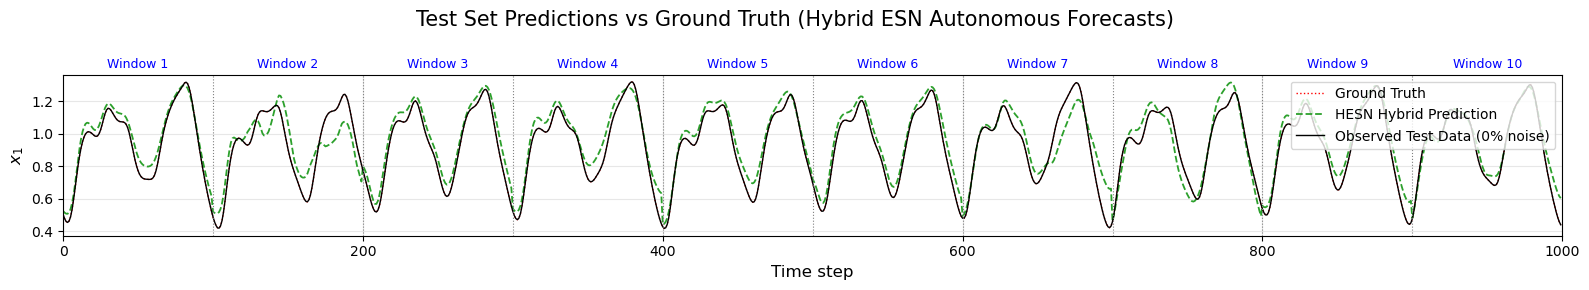

Saved plot as: Test_pred_vs_truth_HESN_ridge1.0e-02_noise0.00.png


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Visualization: HESN Predictions vs Ground Truth
# ============================================================

# Data setup
U_test_noisy = U_rk4[val_end + 1:test_end + 1, :]    # test input (possibly noisy)
true_test = U_test_label                             # ground truth
predictions_full = predictions_full_mean              # ensemble mean predictions

num_test_steps, d = true_test.shape
variables = [f"x_{i+1}" for i in range(d)]
num_windows = int(np.ceil(num_test_steps / window_size))

# ============================================================
# Plot results per variable
# ============================================================
fig, axes = plt.subplots(d, 1, figsize=(16, 3*d), sharex=True)
if d == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    # ---- Ground truth ----
    ax.plot(true_test[:, i],
            label="Ground Truth",
            color="red", linestyle=":", linewidth=1.0)

    # ---- HESN hybrid predictions ----
    ax.plot(predictions_full[:, i],
            label="HESN Hybrid Prediction",
            color="C2", linestyle="--", linewidth=1.3)

    # ---- Observed (noisy) data ----
    ax.plot(U_test_noisy[:, i],
            label=f"Observed Test Data ({noise_scale*100:.0f}% noise)",
            color="black", linewidth=1.0)

    # ---- Mark independent window boundaries ----
    for w in range(1, num_windows):
        ax.axvline(w * window_size, color="gray", linestyle="dotted", linewidth=0.8)

    # ---- Label window centers ----
    ylim = ax.get_ylim()
    for w in range(num_windows):
        center = w * window_size + window_size // 2
        ax.text(center, ylim[1] + 0.02 * (ylim[1] - ylim[0]),
                f"Window {w+1}", ha="center", va="bottom",
                fontsize=9, color="blue")

    # ---- Axis and labels ----
    ax.set_ylabel(f"$x_{{{i+1}}}$", fontsize=12)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")

# ---- Shared X-axis ----
axes[-1].set_xlabel("Time step", fontsize=12)
plt.xlim(0, min(1000, num_test_steps))

# ---- Title ----
fig.suptitle("Test Set Predictions vs Ground Truth (Hybrid ESN Autonomous Forecasts)",
             fontsize=15, y=0.95)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# ---- Save ----
filename = f"Test_pred_vs_truth_HESN_ridge{tikh:.1e}_noise{noise_scale:.2f}.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot as: {filename}")


In [4]:
# ================================
# Save full predictions as .npy file
# ================================
save_info = {
    "MG_predictions_full": predictions_full.astype(np.float32),
    "true_test": true_test.astype(np.float32),
    "U_test_Noisy": U_test_noisy.astype(np.float32),
    "noise_scale": noise_scale,
    "tikhonov": tikh,
    "spectral_radius": rho,
    "input_scaling": input_scaling,
    "leak_factor": leak,
    "connectivity": conn,
    "N_reservoir": N_res,
}

# Informative filename encoding key parameters
save_name = (
    f"MG_predictions_HESN_rho{rho:.2f}_input{input_scaling:.2f}_leak{leak:.2f}_"
    f"tikh{tikh:.1e}_conn{conn:.2f}_noise{noise_scale:.2f}_Nres{N_res}_valtestwashout{val_washout_size}.npy"
)

np.save(save_name, save_info)
print(f"Saved predictions and metadata as: {save_name}")



Saved predictions and metadata as: MG_predictions_HESN_rho1.55_input0.80_leak0.40_tikh1.0e-02_conn0.15_noise0.00_Nres100_valtestwashout1000.npy
